In [113]:
what_are_we_covering = {1:"data laoding",
                        2:"build model",
                        3:"fitting model to data",
                        4:"making predictions",
                        5:"saving and laoding model",
                        6:"putting all togather"}

In [114]:
print(what_are_we_covering)

{1: 'data laoding', 2: 'build model', 3: 'fitting model to data', 4: 'making predictions', 5: 'saving and laoding model', 6: 'putting all togather'}


In [115]:
import torch
from torch import nn #nn contains every thing we need to build a model
import matplotlib.pyplot as plt


In [116]:
torch.__version__

'2.11.0+cu128'

In [117]:
#DATA preparing
#data can be everthing
#images
#videos
#audios
#text


In [118]:
#machine is game of two parts
#1 get data in numerical representation
#2 build model to learn patterns in numerical data


In [119]:
# using linear regresion
# y = a+Bx
#y is depedent
# b  is slop


In [120]:
#create a parmemters
weight  = 0.7
bias = 0.3
#create a some data
start =0
end = 1
step = 0.02
X =torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X+bias
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [121]:
len(X)

50

In [122]:

### spliitng data into and test sets
train_split = int(0.8*len(X))
train_split

40

In [123]:
X_train , y_train = X[:train_split],y[:train_split]
X_test , y_test = X[train_split:],y[train_split:]
len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [124]:
# how we might visulize our data?

In [125]:
def plot_predictions(train_data = X_train,
                    train_labels = y_train,
                     test_data = X_test,
                     test_labels =y_test,
                     predictions = None):
  """
  plots training data, test data and compares it
  """
  plt.scatter(train_data,train_labels,c = "b", s=4,label = "training data")
  #plot testing data
  plt.scatter(test_data,test_labels,c="g",s=4,label = "testing data")
  #are there predictions
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r",s=4,label = "predictions")
  #show the legend
  plt.legend(prop={"size":14})

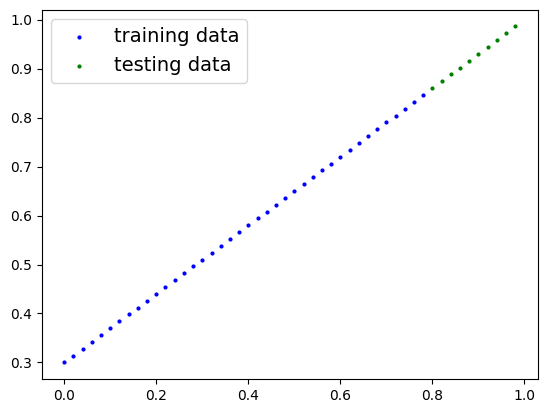

In [126]:
plot_predictions()

In [127]:
from torch import nn
#lets build model
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1,
                                           requires_grad=True,
                                           dtype=torch.float))
    #parameters for  bias
    self.bias = nn.Parameter(torch.randn(1,
                                        requires_grad=True,
                                        dtype=torch.float))
    #now forward method to define computation in the model
  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.weight*x+self.bias # it means this linear regression formula

In [128]:
#whats inside model
#create random seed
torch.manual_seed(42)
#create instance of model
model_0 = LinearRegressionModel()
#check model parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [129]:
#making predictions
with torch.inference_mode():
  y_preds = model_0(X_test)
  y_preds

In [130]:
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [131]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

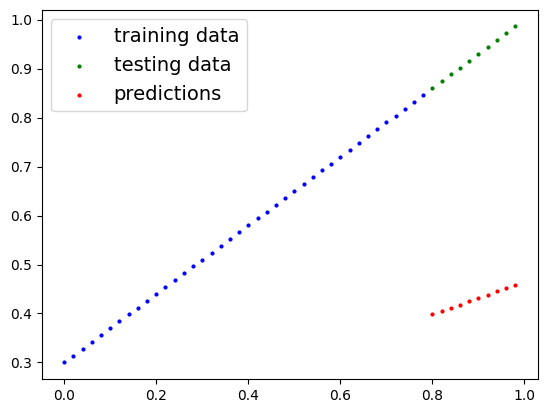

In [132]:
plot_predictions(predictions=y_preds)

### the whole idea is to move from some unknown parameters to some known parameters

## using loss function to find the error

In [133]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [134]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [135]:
#asetup loss fuction
loss_fn = nn.L1Loss()

In [136]:
loss_fn

L1Loss()

In [137]:
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)  #most important hyperaparameters


In [138]:
epoch = 120
#track differnet values
epoch_count = []
loss_values = []
test_loss_values = []
for epoch in range(epoch):
  model_0.train()
  #foward pass
  y_pred = model_0(X_train)
  #calculate loss
  loss = loss_fn(y_pred,y_train)

  #optimization zero grad
  optimizer.zero_grad()
  #perform backpropagation on the loss
  loss.backward()
  #perform gradirnt decent
  optimizer.step()

  model_0.eval() # turns of different settings needed for evaluation
  with torch.inference_mode(): # turns off gradiet tracking and couples of more things
    with torch.no_grad():
      test_pred = model_0(X_test)
      test_loss = loss_fn(test_pred,y_test)
      if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"epoch: {epoch} | loss: {loss} | test loss: {test_loss}")


epoch: 0 | loss: 0.31288138031959534 | test loss: 0.48106518387794495
epoch: 10 | loss: 0.1976713240146637 | test loss: 0.3463551998138428
epoch: 20 | loss: 0.08908725529909134 | test loss: 0.21729660034179688
epoch: 30 | loss: 0.053148526698350906 | test loss: 0.14464017748832703
epoch: 40 | loss: 0.04543796554207802 | test loss: 0.11360953003168106
epoch: 50 | loss: 0.04167863354086876 | test loss: 0.09919948130846024
epoch: 60 | loss: 0.03818932920694351 | test loss: 0.08886633068323135
epoch: 70 | loss: 0.03476089984178543 | test loss: 0.0805937647819519
epoch: 80 | loss: 0.03132382780313492 | test loss: 0.07232122868299484
epoch: 90 | loss: 0.02788739837706089 | test loss: 0.06473556160926819
epoch: 100 | loss: 0.024458957836031914 | test loss: 0.05646304413676262
epoch: 110 | loss: 0.021020207554101944 | test loss: 0.04819049686193466


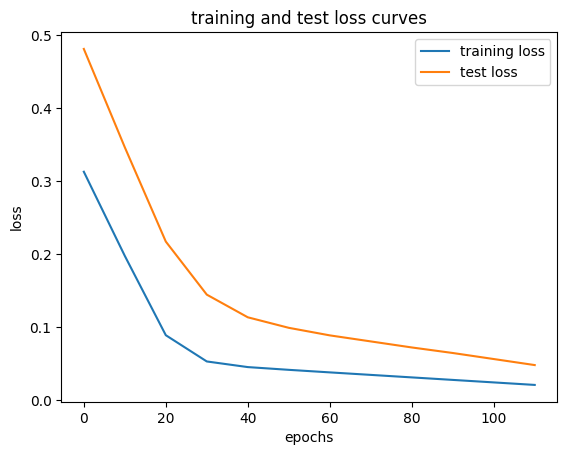

In [139]:
import numpy as np
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()),label = "training loss")
plt.plot(epoch_count,test_loss_values,label = "test loss")
plt.title("training and test loss curves")
plt.ylabel("loss")
plt.xlabel("epochs")
plt.legend()

In [140]:
print(f"loss: {loss}")
print(model_0.state_dict())

loss: 0.017930403351783752
OrderedDict({'weight': tensor([0.6126]), 'bias': tensor([0.3368])})


In [141]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6126])), ('bias', tensor([0.3368]))])

In [142]:
with torch.inference_mode():
  y_predss = model_0(X_test)

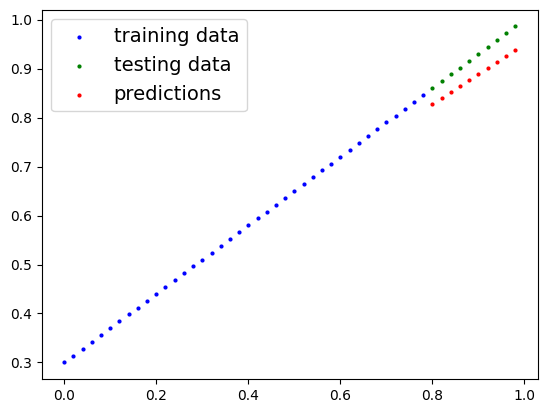

In [143]:
plot_predictions(predictions=y_predss)

In [144]:
#saving model in pytorch
model_0.state_dict()

OrderedDict([('weight', tensor([0.6126])), ('bias', tensor([0.3368]))])

In [145]:
from pathlib import Path
# creates model directory
Model_path=Path("model")
Model_path.mkdir(parents=True,exist_ok=True)
# create model save path
Model_Name = "pytorch2.pth"
Model_Save_Path = Model_path / Model_Name
torch.save(obj=model_0.state_dict(),
           f=Model_Save_Path)
Model_Save_Path

PosixPath('model/pytorch2.pth')

In [146]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.6126])), ('bias', tensor([0.3368]))])

In [147]:
loaded_model_0=LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=Model_Save_Path))

<All keys matched successfully>

In [148]:
loaded_model_0.state_dict()

OrderedDict([('weight', tensor([0.6126])), ('bias', tensor([0.3368]))])

In [149]:
loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds=loaded_model_0(X_test)
loaded_model_preds

tensor([[0.8269],
        [0.8391],
        [0.8514],
        [0.8636],
        [0.8759],
        [0.8881],
        [0.9004],
        [0.9126],
        [0.9249],
        [0.9371]])

In [150]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)

y_preds


tensor([[0.8269],
        [0.8391],
        [0.8514],
        [0.8636],
        [0.8759],
        [0.8881],
        [0.9004],
        [0.9126],
        [0.9249],
        [0.9371]])

In [151]:
y_preds==loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [152]:
#putting all togather
# LETS GO  BACK AND SEE IN ONE PLACE

In [153]:
import torch
from torch import nn
import matplotlib.pyplot as plt
#check pytorch version
torch.__version__

'2.11.0+cu128'

## create device agnostic code
this means if we got gpu our code will use it
potentially for faster computing
if no gpu is available code will default to using cpu

In [154]:
# setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device : {device}")

using device : cuda


In [155]:
# 1
# lets create some data using linear regression formula y = WX+B
weight = 0.7
bias = 0.3
#create range values
start = 0
end = 1
step = 0.02
#create X and y
X = torch.arange(start, end,step).unsqueeze(dim=1)
y = weight*X + bias
X[:10] , y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [156]:
#split data
train_split=int(0.8*len(X))
train_split

40

In [157]:
x_train,y_train = X[:train_split],y[:train_split]
x_test , y_test = X[train_split:],y[train_split:]
len(x_train) , len(y_train) , len(x_test) , len(y_test)

(40, 40, 10, 10)

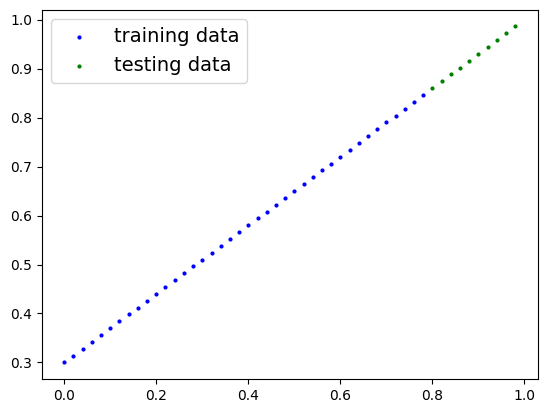

In [158]:
#plot the data
plot_predictions(x_train , y_train , x_test, y_test)

## 2
## building pytorch linear model

In [159]:
class LinearRegressionModelv2(nn.Module):
  def __init__(self):
    super().__init__()
    # use nn.linear()  for creating model's parameters
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)
  def forward(self,x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)
#st manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelv2()
model_1,model_1.state_dict()

(LinearRegressionModelv2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [160]:
next(model_1.parameters()).device

device(type='cpu')

In [161]:
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

## training


*   loss function
*   optimizer
*   training loop
*   testing loop




In [162]:
#setup our loss function
loss_fn = nn.L1Loss()

In [163]:
# setup our optimizers
optimizer = torch.optim.SGD(params = model_1.parameters(),lr = 0.01)


In [166]:
epochs = 200
x_train,y_train = x_train.to(device),y_train.to(device)
x_test,y_test = x_test.to(device),y_test.to(device)
for epoch in range(epochs):
    model_1.train()

    y_pred = model_1(x_train)

    loss = loss_fn(y_pred,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    #testing
    model_1.eval()
    with torch.inference_mode():
      test_pred = model_1(x_test)
      test_loss = loss_fn(test_pred,y_test)

    #print out whats happening
    if epoch % 10 == 0:
      print(f"epoch:{epoch},Loss : {loss}, Test_loss :{test_loss}")


epoch:0,Loss : 0.5551779270172119, Test_loss :0.5739762187004089
epoch:10,Loss : 0.4399681091308594, Test_loss :0.4392664134502411
epoch:20,Loss : 0.3247582018375397, Test_loss :0.30455657839775085
epoch:30,Loss : 0.20954833924770355, Test_loss :0.16984669864177704
epoch:40,Loss : 0.09433844685554504, Test_loss :0.03513690456748009
epoch:50,Loss : 0.023886388167738914, Test_loss :0.04784907028079033
epoch:60,Loss : 0.019956795498728752, Test_loss :0.045803118497133255
epoch:70,Loss : 0.016517987474799156, Test_loss :0.037530567497015
epoch:80,Loss : 0.013089174404740334, Test_loss :0.02994490973651409
epoch:90,Loss : 0.009653178043663502, Test_loss :0.02167237363755703
epoch:100,Loss : 0.006215683650225401, Test_loss :0.014086711220443249
epoch:110,Loss : 0.00278724217787385, Test_loss :0.005814164876937866
epoch:120,Loss : 0.0012645035749301314, Test_loss :0.013801801018416882
epoch:130,Loss : 0.0012645035749301314, Test_loss :0.013801801018416882
epoch:140,Loss : 0.001264503574930131

In [168]:
print(model_1.state_dict())


OrderedDict({'linear_layer.weight': tensor([[0.6968]], device='cuda:0'), 'linear_layer.bias': tensor([0.3025], device='cuda:0')})


In [169]:
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(x_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

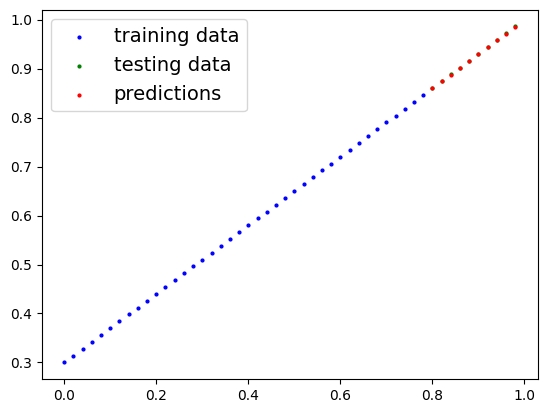

In [172]:
plot_predictions(predictions=y_preds.cpu())

In [177]:
# saving model_1
from pathlib import Path
Model_Path = Path("models")
Model_Path.mkdir(parents=True,exist_ok=True)

Model_Name="Model_1.pth"
MODEL_SAVE_PATH = Model_Path/Model_Name

torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

In [180]:
loaded_model_1 = LinearRegressionModelv2()
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_1.to(device)

LinearRegressionModelv2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)